In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kundanbedmutha/student-performance-dataset/Student_Performance.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("kundanbedmutha/student-performance-dataset")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/kundanbedmutha/student-performance-dataset/Student_Performance.csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [5]:
df.isna().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [6]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [7]:
#feature
df['total_marks'] = (
    df['math_score'] +
    df['science_score'] +
    df['english_score']
)

df[['math_score', 'science_score', 'english_score', 'overall_score', 'total_marks']].head()

,math_score,science_score,english_score,overall_score,total_marks
0,42.7,55.4,57.0,53.1,155.1
1,57.6,68.8,64.8,61.3,191.2
2,84.8,95.0,79.2,89.6,259.0
3,44.4,27.5,54.7,41.6,126.6
4,8.9,32.7,30.0,25.4,71.6


In [8]:
df['total_marks'].describe()

count    25000.000000
mean       191.213212
std         57.971126
min         21.300000
25%        146.575000
50%        192.600000
75%        237.100000
max        300.000000
Name: total_marks, dtype: float64

In [9]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(df[col].value_counts())
    print()

gender
other     8463
female    8290
male      8247
Name: count, dtype: int64

school_type
private    12725
public     12275
Name: count, dtype: int64

parent_education
diploma          4314
high school      4205
post graduate    4196
graduate         4127
no formal        4079
phd              4079
Name: count, dtype: int64

internet_access
yes    21227
no      3773
Name: count, dtype: int64

travel_time
15-30 min    6362
30-60 min    6345
>60 min      6166
<15 min      6127
Name: count, dtype: int64

extra_activities
yes    12500
no     12500
Name: count, dtype: int64

study_method
mixed            4341
textbook         4239
notes            4165
online videos    4139
group study      4090
coaching         4026
Name: count, dtype: int64

final_grade
d    6311
c    6161
e    5672
f    2955
b    2696
a    1205
Name: count, dtype: int64



In [10]:
#corr with total
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()['total_marks'].sort_values(ascending=False)
print(corr)

total_marks              1.000000
overall_score            0.955766
math_score               0.925773
english_score            0.925411
science_score            0.925280
study_hours              0.868414
attendance_percentage    0.273233
student_id               0.000848
age                     -0.004418
Name: total_marks, dtype: float64


In [11]:
#need help?
df['needs_help'] = (df['total_marks'] < 150).astype(int)
print(df['needs_help'].value_counts())

needs_help
0    18373
1     6627
Name: count, dtype: int64


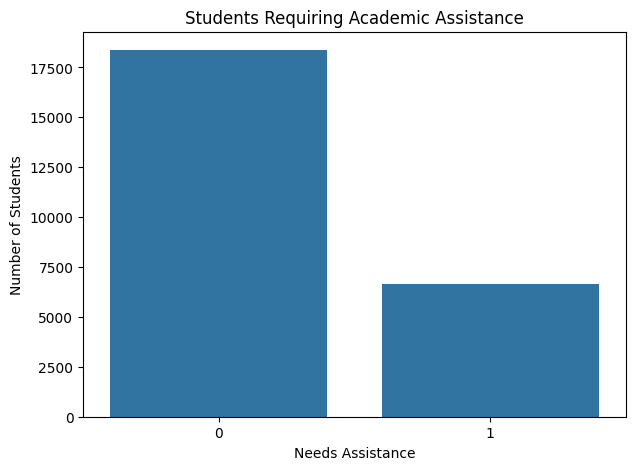

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='needs_help')
plt.title('Students Requiring Academic Assistance')
plt.xlabel('Needs Assistance')
plt.ylabel('Number of Students')

plt.show()

Make regression and classification both (this is for learning. If you see mistakes, that cause I am learning)

In [13]:
features = [
    'age',
    'gender',
    'school_type',
    'parent_education',
    'study_hours',
    'attendance_percentage',
    'internet_access',
    'travel_time',
    'extra_activities',
    'study_method'
]

X = df[features]

y_reg = df['total_marks']
y_clf = df['needs_help']

print("Features:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Regression target:", y_reg.shape)
print("Classification target:", y_clf.shape)

Features:
['age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method']

Shape of X: (25000, 10)
Regression target: (25000,)
Classification target: (25000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['age', 'study_hours', 'attendance_percentage']
Categorical features: ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']


# **Regression Models**

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train models
lr_model.fit(X_train, y_reg_train)
rf_model.fit(X_train, y_reg_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'study_hours',
                                                   'attendance_percentage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'school_type',
                                                   'parent_education',
                                                   'internet_access',
                                                   'travel_time',
                                                   'extra_activities',
                                                   'study_method'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_reg_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_pred))
lr_r2 = r2_score(y_reg_test, lr_pred)

rf_mae = mean_absolute_error(y_reg_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_pred))
rf_r2 = r2_score(y_reg_test, rf_pred)

print("Linear Regression")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

print("\nRandom Forest Regressor")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Linear Regression
MAE  : 19.2121
RMSE : 23.7221
R²   : 0.8347

Random Forest Regressor
MAE  : 11.5662
RMSE : 16.9923
R²   : 0.9152


# **Classification Models**

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

lr_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

lr_clf.fit(X_train, y_clf_train)
rf_clf.fit(X_train, y_clf_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'study_hours',
                                                   'attendance_percentage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'school_type',
                                                   'parent_education',
                                                   'internet_access',
                                                   'travel_time',
                                                   'extra_activities',
                                                   'study_method'])])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions
lr_clf_pred = lr_clf.predict(X_test)
rf_clf_pred = rf_clf.predict(X_test)

# Logistic Regression
print("Logistic Regression")
print(f"Accuracy  : {accuracy_score(y_clf_test, lr_clf_pred):.4f}")
print(f"Precision : {precision_score(y_clf_test, lr_clf_pred):.4f}")
print(f"Recall    : {recall_score(y_clf_test, lr_clf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_clf_test, lr_clf_pred):.4f}")

# Random Forest Classifier
print("\nRandom Forest Classifier")
print(f"Accuracy  : {accuracy_score(y_clf_test, rf_clf_pred):.4f}")
print(f"Precision : {precision_score(y_clf_test, rf_clf_pred):.4f}")
print(f"Recall    : {recall_score(y_clf_test, rf_clf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_clf_test, rf_clf_pred):.4f}")

Logistic Regression
Accuracy  : 0.8956
Precision : 0.8096
Recall    : 0.7925
F1 Score  : 0.8009

Random Forest Classifier
Accuracy  : 0.9592
Precision : 0.9275
Recall    : 0.9177
F1 Score  : 0.9226


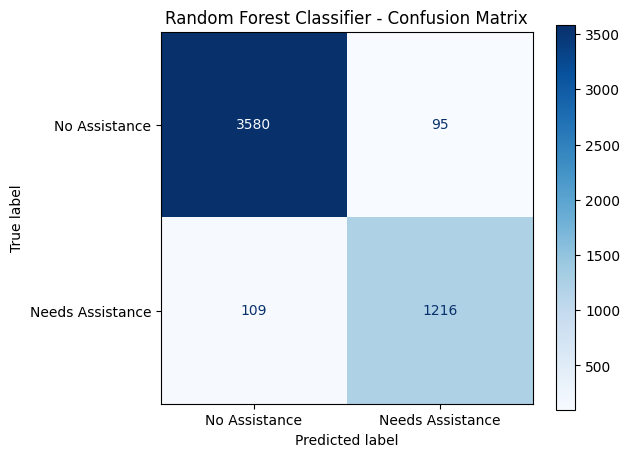

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_clf_test,
    rf_clf_pred,
    display_labels=["No Assistance", "Needs Assistance"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Random Forest Classifier - Confusion Matrix")
plt.show()

In [21]:
# Get feature names after preprocessing
feature_names = rf_clf.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from Random Forest
importances = rf_clf.named_steps['model'].feature_importances_

# Create a dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15))

                           Feature  Importance
1                 num__study_hours    0.587021
2       num__attendance_percentage    0.147572
0                         num__age    0.046270
4                 cat__gender_male    0.010565
17      cat__travel_time_30-60 min    0.010448
18        cat__travel_time_<15 min    0.010326
3               cat__gender_female    0.010282
5                cat__gender_other    0.010216
16      cat__travel_time_15-30 min    0.010188
6         cat__school_type_private    0.010020
7          cat__school_type_public    0.009942
24         cat__study_method_mixed    0.009255
21       cat__extra_activities_yes    0.009007
9   cat__parent_education_graduate    0.009006
19        cat__travel_time_>60 min    0.008996
